## Visualiza trajectory map for different source.

### Environment Setup

In [10]:
# Import package
import numpy as np

from pathlib import Path

from matplotlib import pyplot as plt

# Path setup

root_path: Path = Path("/Users/joseph/Desktop/NTU Course/114-2/Data Assimilation/Project")
file_path: Path = root_path / "Files"
fig_path : Path = root_path / "Figure"

plt.style.use(root_path / "Code" / "src" / "stylelist.mplstyle")


### Load data

In [11]:
# data name
data_name: str = "incremental_3DVar/NMC/on_X-Y-Z"
title_name: str = "Incremental 3DVar (on X-Y-Z)"

type_list: list = data_name.split("/")

# Load data
traj_dict: dict[str, np.ndarray] = dict(np.load(file_path / "traj" / f"{data_name}.npz"))

### Visualization

#### Hovmöller diagram

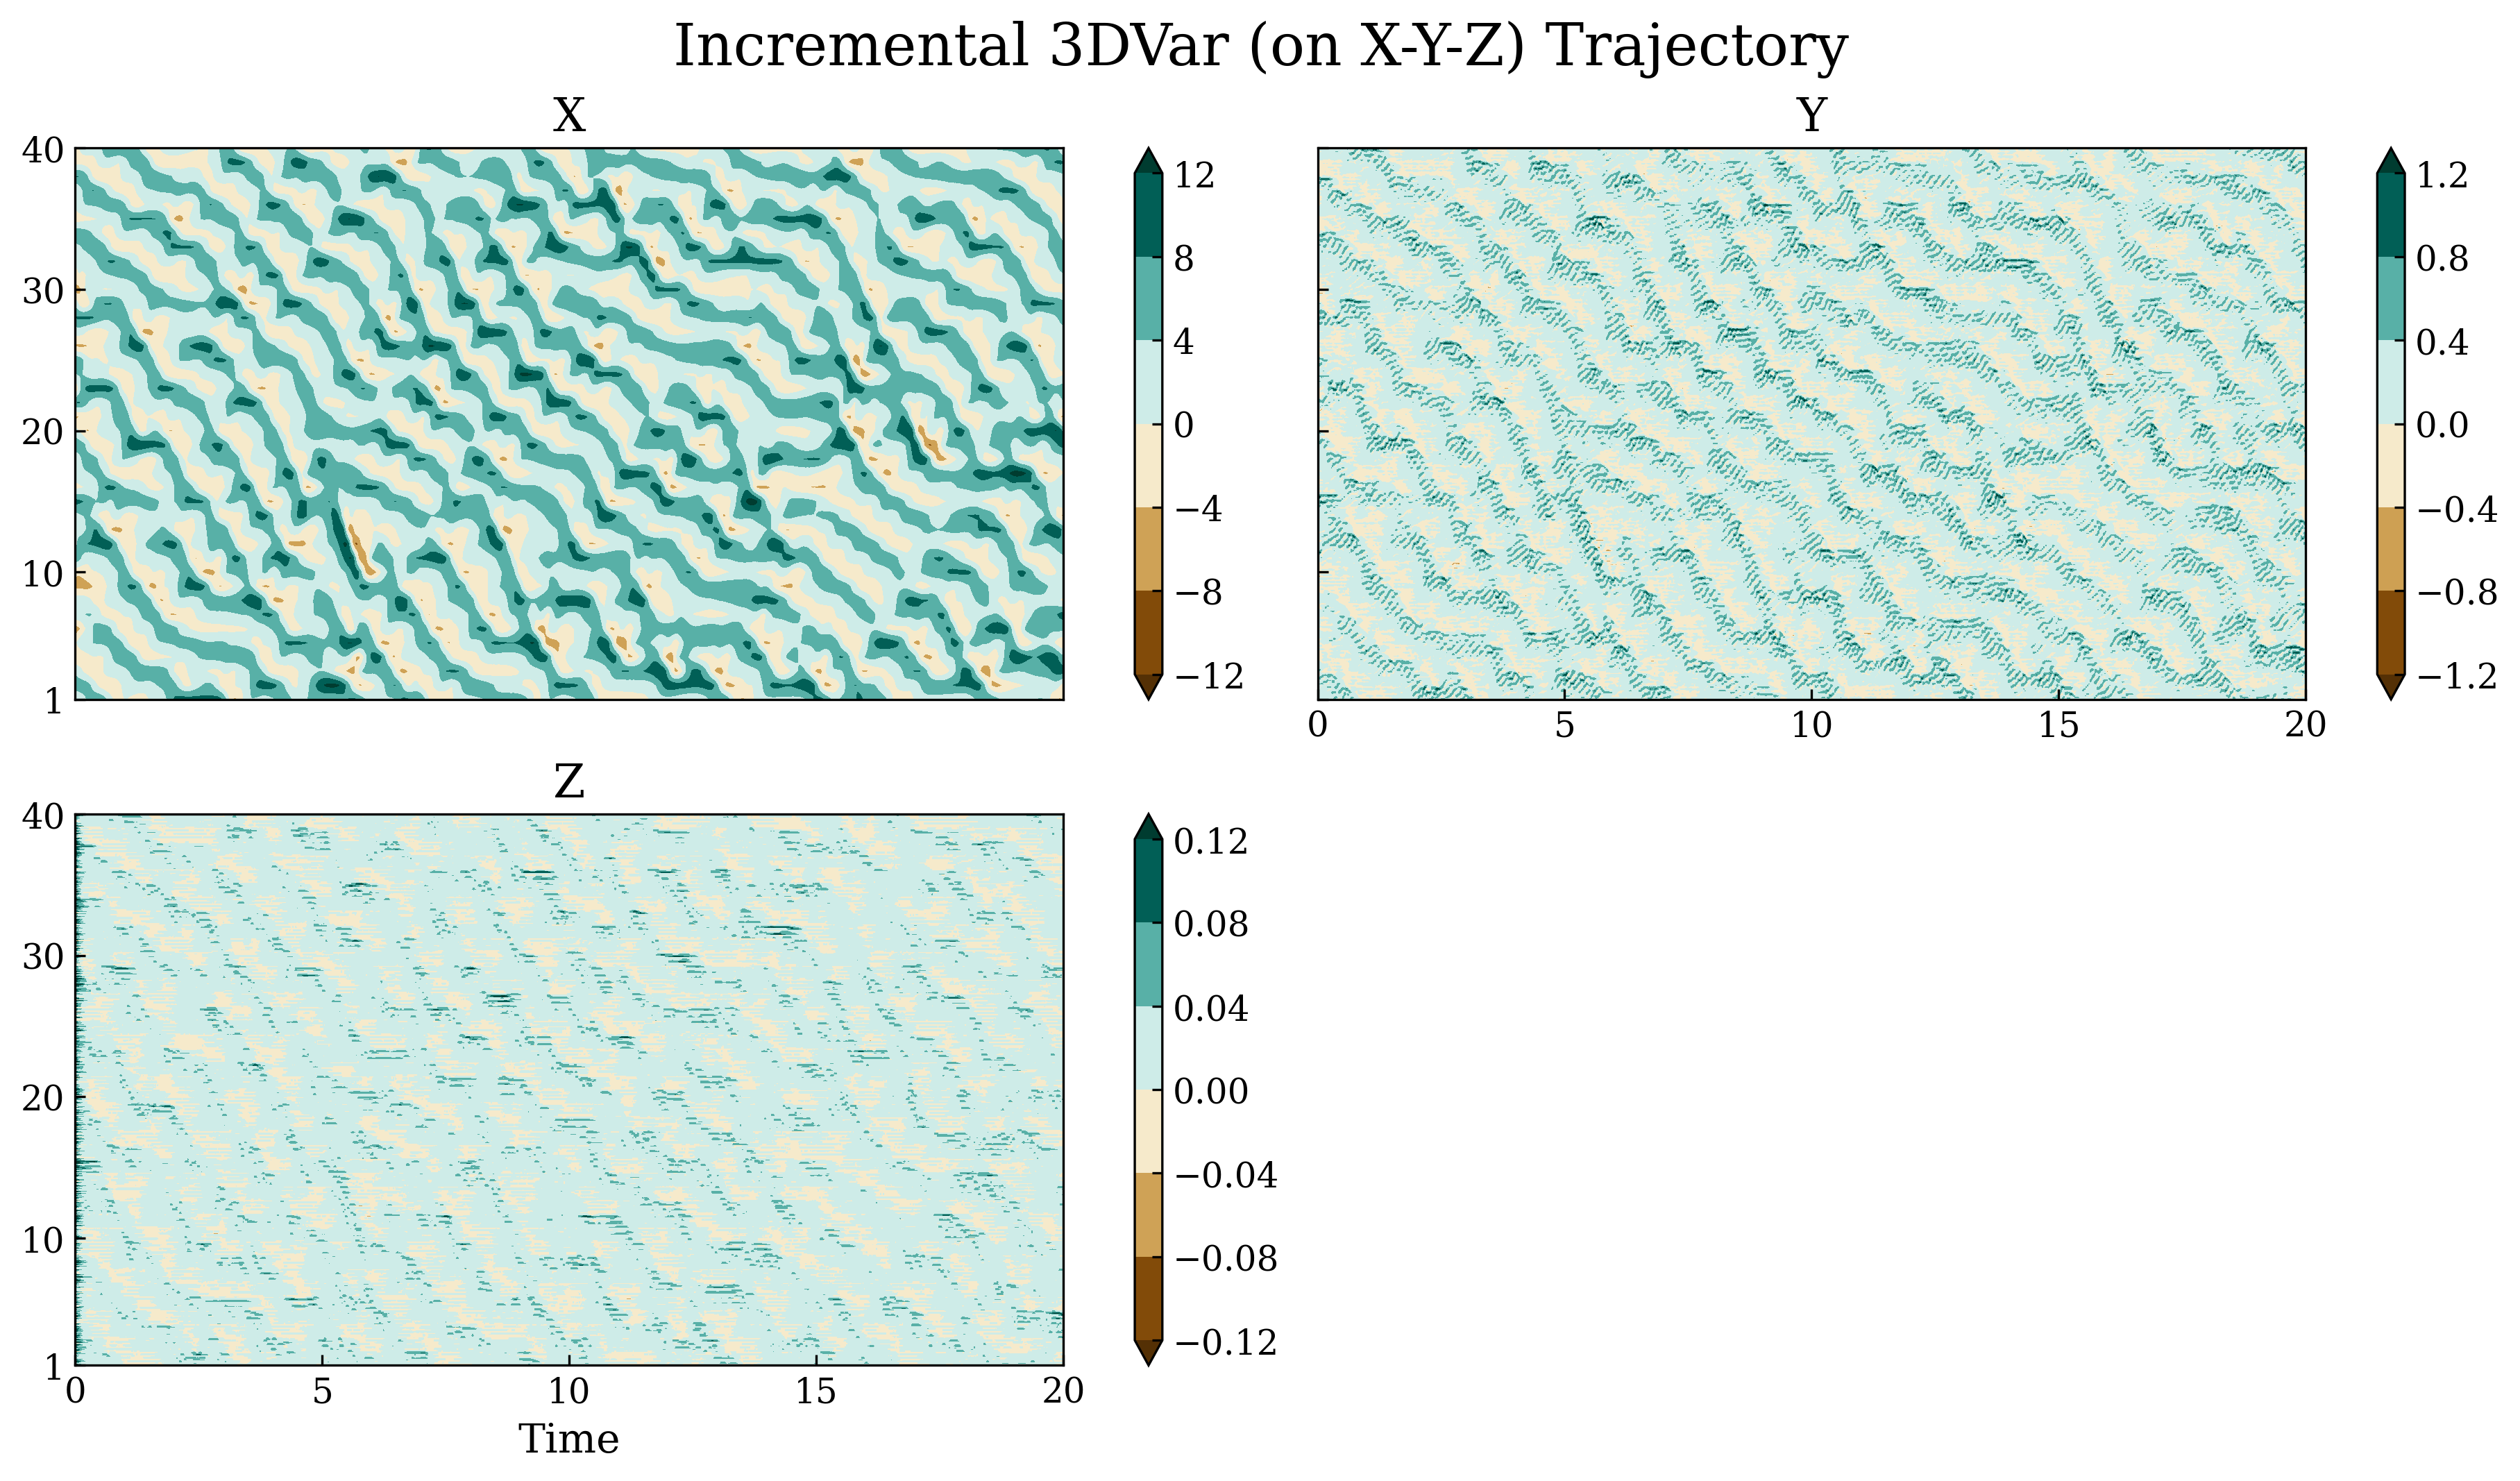

In [12]:
# time and Space coordinate
import os


time: np.ndarray = np.arange(0, 20, 0.01)
Xgrid: np.ndarray = np.linspace(1, 40, traj_dict["X"].shape[1])
Ygrid: np.ndarray = np.linspace(1, 40, np.prod(traj_dict["Y"].shape[1:]))
Zgrid: np.ndarray = np.linspace(1, 40, np.prod(traj_dict["Z"].shape[1:]))

# visualize
fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharey="row")

X_ctf = ax[0, 0].contourf(
    time, Xgrid,
    traj_dict["X"][:2000].T,
    levels = [-12, -8, -4, 0, 4, 8, 12],
    cmap="BrBG", extend="both"
)

ax[0, 0].set_xticks([])
ax[0, 0].set_yticks([1, 10, 20, 30, 40])
ax[0, 0].set_title("X")


fig.colorbar(X_ctf, ax=ax[0, 0])

Y_ctf = ax[0, 1].contourf(
    time, Ygrid,
    traj_dict["Y"][:2000].reshape(2000, -1).T,
    levels = [-1.2, -0.8, -0.4, 0, 0.4, 0.8, 1.2],
    cmap="BrBG", extend="both"
)
ax[0, 1].set_xticks([0, 5, 10, 15, 20])
ax[0, 1].set_title("Y")

fig.colorbar(Y_ctf, ax=ax[0, 1])

Z_ctf = ax[1, 0].contourf(
    time, Zgrid,
    traj_dict["Z"][:2000].reshape(2000, -1).T,
    levels = [-0.12, -0.08, -0.04, 0, 0.04, 0.08, 0.12],
    cmap="BrBG", extend="both"
)

ax[1, 0].set_xlabel("Time")
ax[1, 0].set_xticks([0, 5, 10, 15, 20])
ax[1, 0].set_yticks([1, 10, 20, 30, 40])
ax[1, 0].set_title("Z")
fig.colorbar(Z_ctf, ax=ax[1, 0])

ax[1,1].axis("off")

plt.suptitle(f"{title_name} Trajectory", fontsize=20)

os.makedirs(fig_path / "traj" / f"{data_name.split('/')[0]}", exist_ok=True)

plt.savefig(fig_path / "traj" / type_list[0] / f"{type_list[-1]}.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()